## Predictive Modelling

`This project converts the findings from the previous fraud-detection projects into a supervised Machine Learning system capable of predicting whether a transaction is legitimate or fraudulent.`
+ Predictive Modelling is designed to solve the financial-security problem by learning from historical transaction patterns and predicting whether new transactions are potentially fraudulent.

### An understanding of Model-Making based on Fraud_Detection:
Fraud detection is not simply about understanding what happened in previous transactions. A practical security system must use historical patterns to make decisions about future transactions. Machine Learning makes this possible by learning relationships between transaction characteristics and previously identified fraud cases.

In this project, the is_fraud variable becomes the prediction target, transforming the problem into a supervised binary classification task. Numerical and categorical transaction characteristics are converted into machine-readable features, after which multiple Machine Learning algorithms are trained and evaluated.

Because fraud is relatively rare compared with legitimate activity, model performance cannot be judged by accuracy alone. A model that labels almost every transaction as legitimate could achieve high accuracy while failing to detect the very fraud we care about. Therefore, this project emphasizes precision, recall, F1-score, ROC-AUC, and the confusion matrix when comparing models.

***The final objective is to identify a model that provides a useful balance between detecting fraudulent transactions and avoiding unnecessary disruption to legitimate customers.***

### Exploring DATA
Suppose, a customer makes a transcation of X amount on an Online Platform at time(02:00 AM) to previously known Merchant, but at a different Geographic Location... 

A traditional rule might say:
**Large transaction at night = fraud.**

But that is far too simplistic, and `might not even be 100% true`!!

Machine Learning instead asks:
`"Considering all available transaction characteristics together, how likely is this transaction to belong to the fraudulent class?"`

That is what we are going to build.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
train_path = Path("../Datasets_MLmodels/Fraud/P03_outputs/fraudTrain_clean.csv")
test_path = Path("../Datasets_MLmodels/Fraud/P03_outputs/fraudTest_clean.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (1296675, 22)
Testing shape: (555719, 22)


In [3]:
target = "is_fraud"

X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]

print("Features:", X_train.shape[1])
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Features: 21
Training observations: 1296675
Testing observations: 555719


In [4]:
drop_columns = ["trans_num", "cc_num"]

X_train = X_train.drop(columns=drop_columns, errors="ignore")
X_test = X_test.drop(columns=drop_columns, errors="ignore")

In [5]:
for df in [X_train, X_test]:
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    
    df["transaction_hour"] = (df["trans_date_trans_time"].dt.hour)
  
    df["transaction_day"] = (df["trans_date_trans_time"].dt.day)
    
    df["transaction_month"] = (df["trans_date_trans_time"].dt.month)
    
    df["transaction_weekday"] = (df["trans_date_trans_time"].dt.dayofweek)
    
    df.drop(columns="trans_date_trans_time", inplace=True)

In [6]:
for df in [X_train, X_test]:
    if "dob" in df.columns:
        df.drop(
            columns="dob",
            inplace=True
        )

In [7]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_weekday']

Categorical features:
['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job']


In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [9]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features) ,
    ( "categorical", categorical_pipeline, categorical_features)
])

In [10]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ( "model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [11]:
class_weight="balanced"

In [12]:
logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [13]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]

In [14]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)
lr_precision = precision_score(
    y_test,
    y_pred_lr
)
lr_recall = recall_score(
    y_test,
    y_pred_lr
)
lr_f1 = f1_score(
    y_test,
    y_pred_lr
)
lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.9237
Precision: 0.0054
Recall   : 0.103
F1-score : 0.0103
ROC-AUC  : 0.462


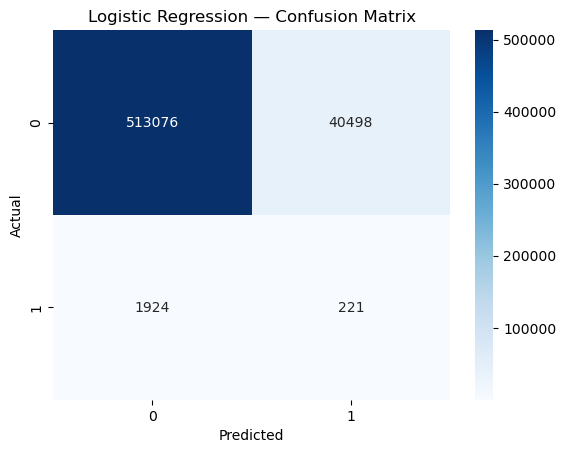

In [15]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=15,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
    )
    )
])

In [17]:
random_forest.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [18]:
y_pred_rf = random_forest.predict(
    X_test
)

y_prob_rf = random_forest.predict_proba(
    X_test
)[:, 1]

In [19]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)
rf_precision = precision_score(
    y_test,
    y_pred_rf
)
rf_recall = recall_score(
    y_test,
    y_pred_rf
)
rf_f1 = f1_score(
    y_test,
    y_pred_rf
)
rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
-------------
Accuracy : 0.9762
Precision: 0.1085
Recall   : 0.7147
F1-score : 0.1884
ROC-AUC  : 0.9051


In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [lr_accuracy, rf_accuracy],

    "Precision": [lr_precision, rf_precision],

    "Recall": [lr_recall, rf_recall],

    "F1": [lr_f1, rf_f1],

    "ROC_AUC": [lr_auc, rf_auc]
})

results = results.round(4)
#print(results)
results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.9237,0.0054,0.1030,0.0103,0.4620
1,Random Forest,0.9762,0.1085,0.7147,0.1884,0.9051


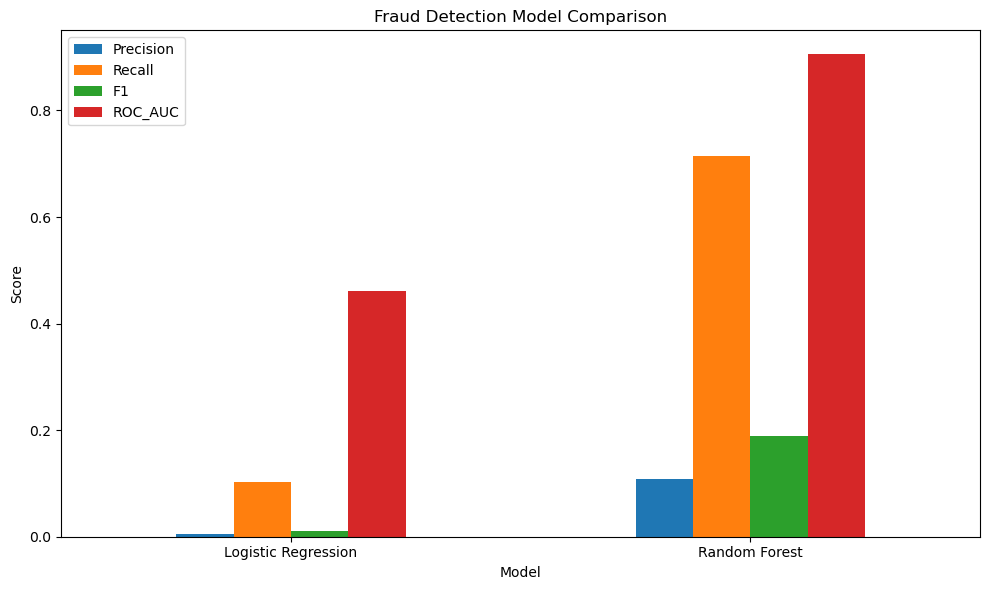

In [21]:
results_plot = results.set_index("Model")

results_plot[
    ["Precision", "Recall", "F1", "ROC_AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Detection Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
best_model_name = results.loc[
    results["F1"].idxmax(),
    "Model"
]
print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Random Forest


In [23]:
if best_model_name == "Logistic Regression":
    best_predictions = y_pred_lr
else:
    best_predictions = y_pred_rf

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Legitimate", "Fraudulent"]
    ))

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    553574
  Fraudulent       0.11      0.71      0.19      2145

    accuracy                           0.98    555719
   macro avg       0.55      0.85      0.59    555719
weighted avg       1.00      0.98      0.98    555719



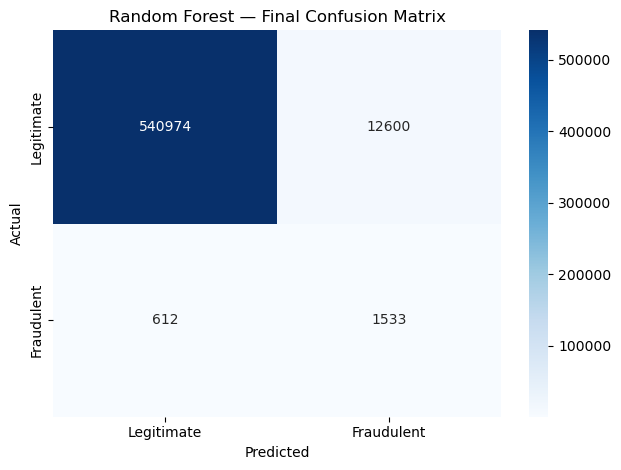

In [24]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title(
    f"{best_model_name} — Final Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [25]:
output_dir = Path("../Datasets_MLmodels/Fraud/P07_outputs")
output_dir.mkdir(exist_ok=True)

results.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

In [26]:
prediction_output = test.copy()

prediction_output["predicted_fraud"] = (best_predictions)
prediction_output.to_csv(
    output_dir / "fraud_predictions.csv",
    index=False
)

In [27]:
print("=" * 65)
print("\t\t\tPROJECT 07 COMPLETED")
print("=" * 65)

print(f"""
Models trained:
- Logistic Regression
- Random Forest

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Best model:
{best_model_name}

The selected model can now be carried forward
for business interpretation and further fraud-risk analysis.
""")

			PROJECT 07 COMPLETED

Models trained:
- Logistic Regression
- Random Forest

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Best model:
Random Forest

The selected model can now be carried forward
for business interpretation and further fraud-risk analysis.

